# Data Loading & Importing Libs

In [ ]:
!pip install librosa

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Music Lib's
import librosa
import librosa.display

from IPython.display import Audio
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: TEST/112.wav            
  inflating: TEST/113.wav            
  inflating: TEST/115.wav            
  inflating: TEST/119.wav            
  inflating: TEST/123.wav            
  inflating: TEST/124.wav            
  inflating: TEST/125.wav            
  inflating: TEST/128.wav            
  inflating: TEST/13.wav             
  inflating: TEST/130.wav            
  inflating: TEST/131.wav            
  inflating: TEST/132.wav            
  inflating: TEST/134.wav            
  inflating: TEST/135.wav            
  inflating: TEST/136.wav            
  inflating: TEST/138.wav            
  inflating: TEST/141.wav            
  inflating: TEST/142.wav            
  inflating: TEST/143.wav            
  inflating: TEST/146.wav            
  inflating: TEST/15.wav             
  inflating: TEST/152.wav            
  inflating: TEST/157.wav            
  inflating: TEST/158.wav            
  inflating: TEST/165.wav            
  inflating: TEST/1

In [ ]:
train_data = pd.read_csv('/content/TRAIN.csv')
train_audio = '/content/TRAIN'
test_audio = '/content/TEST'

# Data Preprocessing

In [ ]:
for index, row in train_data.iterrows():
    print(index, row)

0 Filename     346.wav
Class       Negative
Name: 0, dtype: object
1 Filename    163.wav
Class       Neutral
Name: 1, dtype: object
2 Filename     288.wav
Class       Negative
Name: 2, dtype: object
3 Filename     279.wav
Class       Negative
Name: 3, dtype: object
4 Filename     244.wav
Class       Negative
Name: 4, dtype: object
5 Filename     273.wav
Class       Negative
Name: 5, dtype: object
6 Filename       5.wav
Class       Positive
Name: 6, dtype: object
7 Filename     353.wav
Class       Negative
Name: 7, dtype: object
8 Filename    145.wav
Class       Neutral
Name: 8, dtype: object
9 Filename     109.wav
Class       Positive
Name: 9, dtype: object
10 Filename    211.wav
Class       Neutral
Name: 10, dtype: object
11 Filename      38.wav
Class       Positive
Name: 11, dtype: object
12 Filename    214.wav
Class       Neutral
Name: 12, dtype: object
13 Filename      55.wav
Class       Positive
Name: 13, dtype: object
14 Filename     305.wav
Class       Negative
Name: 14, dtype: 

In [ ]:
def extract_feature(file_name):
    audio, sample_rate = librosa.load(file_name, res_type= 'kaiser_fast')  # This line gives audio time & sample rate.
    mfccs = librosa.feature.mfcc(y= audio, sr= sample_rate, n_mfcc= 40) # Calculate  Mel-Frequency Cepstral Coefficients.
    return np.mean(mfccs.T, axis= 0)

features = []
labels = []

# This loop iterate through each row of train_data and store the row of Filename.
for index, row in train_data.iterrows():
    file_path = os.path.join(train_audio, row['Filename'])
    data = extract_feature(file_path)

    features.append(data)
    labels.append(row['Class'])

# EDA

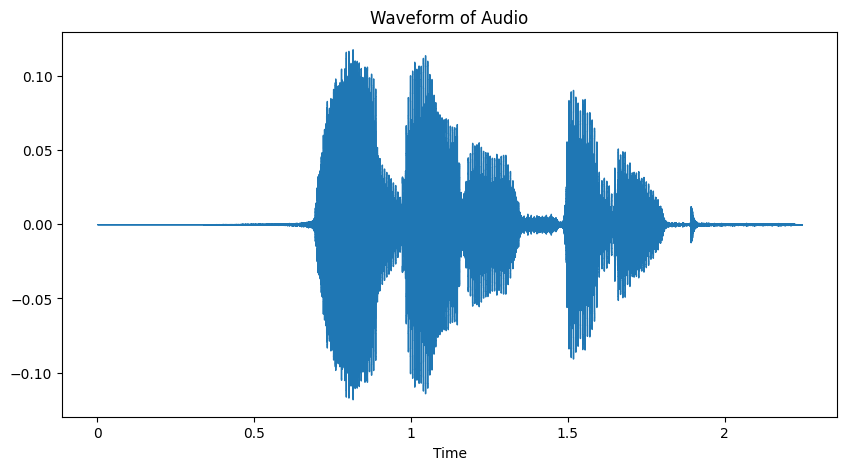

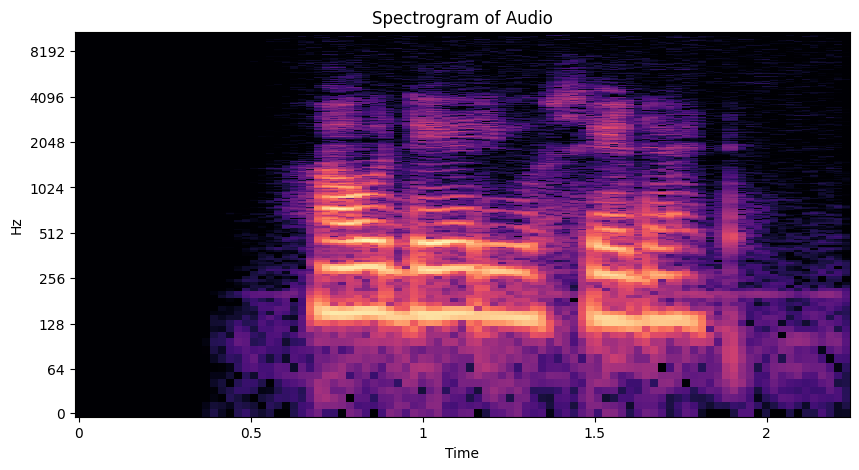

In [ ]:
examp_audio = os.path.join(train_audio, train_data['Filename'].iloc[0])
audio, sample_rate = librosa.load(examp_audio)

# For Waveform
plt.figure(figsize= (10, 5))
librosa.display.waveshow(audio, sr= sample_rate)
plt.title('Waveform of Audio')
plt.show()

# For Spectrogram
plt.figure(figsize= (10, 5))
# This line converts audio into chunks then the complex value is converted into numbers and then amp value into DB.
spectrogram = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref= np.max) # stft = Short-Time Fourier Transform.
librosa.display.specshow(spectrogram, sr= sample_rate, x_axis= 'time', y_axis= 'log')
plt.title('Spectrogram of Audio')
plt.show()

# Data Splitting & Data Traning

In [ ]:
le = LabelEncoder()
x = np.array(features)
y = to_categorical(le.fit_transform(labels))

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size= 0.2, random_state= 42)

# Applying CNN

In [ ]:
x_train = x_train.reshape(x_train.shape[0], 40, 1, 1)
x_val = x_val.reshape(x_val.shape[0], 40, 1, 1)

model = Sequential()
model.add(Conv2D(32, (3, 1), activation= 'relu', input_shape= (40, 1, 1)))
model.add(MaxPooling2D((2, 1)))

model.add(Conv2D(64, (3, 1), activation= 'relu'))
model.add(MaxPooling2D((2, 1)))

model.add(Flatten())
model.add(Dense(128, activation= 'relu'))
model.add(Dense(3, activation= 'softmax')) # 3 reps negative, neutral, positive

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss= 'categorical_crossentropy', optimizer= 'adam', metrics= ['accuracy'])
history = model.fit(x_train, y_train, epochs= 10, batch_size= 32, validation_data= (x_val, y_val))
model.summary()

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 499ms/step - accuracy: 0.3820 - loss: 1.9951 - val_accuracy: 0.6600 - val_loss: 0.7583
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6836 - loss: 0.6962 - val_accuracy: 0.8400 - val_loss: 0.4609
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7778 - loss: 0.4882 - val_accuracy: 0.8800 - val_loss: 0.3272
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8833 - loss: 0.2902 - val_accuracy: 0.9000 - val_loss: 0.3038
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9341 - loss: 0.2369 - val_accuracy: 0.9200 - val_loss: 0.2505
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9713 - loss: 0.1824 - val_accuracy: 0.8800 - val_loss: 0.2963
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8889 - loss: 0.2405 - val_accuracy: 0.8600 - val_loss: 0.2555
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9333 - loss: 0.1926 - val_accuracy: 0.8600 - val_loss: 0.3111

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 38, 1, 32)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 17, 1, 64)      │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,163 (848.30 KB)

 Trainable params: 72,387 (282.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 144,776 (565.54 KB)

# Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8917 - loss: 0.2446
Loss: 0.22759273648262024, Accuracy: 0.8999999761581421
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


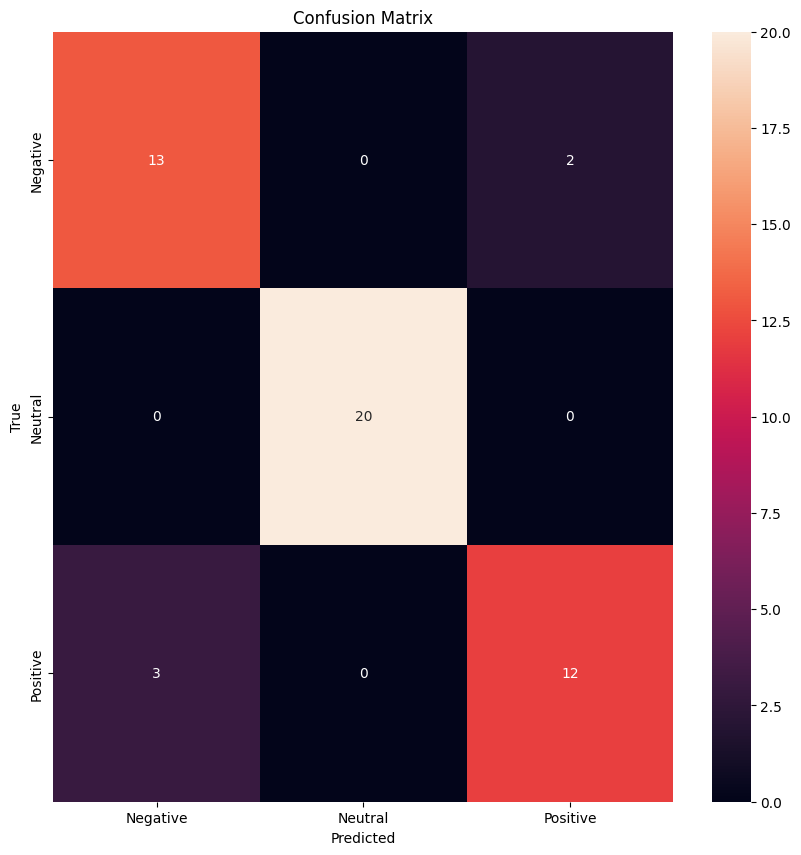

In [ ]:
loss, accuracy = model.evaluate(x_val, y_val)
print(f'Loss: {loss}, Accuracy: {accuracy}')

y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis= 1) # finds the index of the highest probability.
y_true = np.argmax(y_val, axis= 1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize= (10, 10))
sns.heatmap(cm, xticklabels= le.classes_, yticklabels= le.classes_, annot= True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Prediction Func

In [ ]:
def predict_sentiment(audio_path):
    features = extract_feature(audio_path)
    features = features.reshape(1, 40, 1, 1) # 1 in start indicates a single sample.
    prediction = model.predict(features)
    predict_label = le.inverse_transform([np.argmax(prediction)])[0]
    return predict_label

In [ ]:
# Test1

audio_path = '/content/TEST/130.wav'

display = Audio(audio_path, autoplay= True)

predict_label = predict_sentiment(audio_path)
print(f'Predicted Sentiment: {predict_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Predicted Sentiment: Neutral


In [ ]:
# Test2

audio_path = '/content/TRAIN/301.wav'

display = Audio(audio_path, autoplay= True)

predict_label = predict_sentiment(audio_path)
print(f'Predicted Sentiment: {predict_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Sentiment: Negative


# Saving Model

In [ ]:
import pickle

model.save('Audio_sentiment.h5')
pickle.dump(model, open('Audio_sentiment.pkl', 'wb'))